In [1]:
import os

os.environ["ROBOFLOW_API_KEY"] = "J1oKKy8ww5yYkJGO3YUZ"


In [5]:
!nvidia-smi

Sun Oct 12 01:44:14 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.70                 Driver Version: 572.70         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2060      WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   47C    P8             12W /  100W |     553MiB /   6144MiB |     21%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from rfdetr import RFDETRBase

model = RFDETRBase()

DATASET_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\basketball-player-detection-2.v13i.coco"
OUTPUT_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\basketball_output"
EPOCHS = 50
BATCH_SIZE = 4  # Adjust based on GPU memory (T4: 4, A100: 16)
GRAD_ACCUM_STEPS = 16  # Keep total batch size = batch_size * grad_accum_steps = 16
LEARNING_RATE = 1e-4

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# History callback to track metrics
history = []

def callback_on_epoch_end(data):
    """Callback function to store training metrics"""
    history.append(data)
    print(f"Epoch {data.get('epoch', 0)}: Train Loss = {data.get('train_loss', 0):.4f}, "
          f"Val Loss = {data.get('test_loss', 0):.4f}, mAP = {data.get('test_map', 0):.4f}")

# Register callback
model.callbacks["on_fit_epoch_end"].append(callback_on_epoch_end)

print("Model initialized and ready for training!")
print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"Epochs: {EPOCHS}, Batch Size: {BATCH_SIZE}, Grad Accum: {GRAD_ACCUM_STEPS}")

model.train(
    dataset_dir=DATASET_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    lr=LEARNING_RATE,
    output_dir=OUTPUT_DIR,
    use_ema=True,  # Use Exponential Moving Average for better generalization
    tensorboard=False,  # Set to True if you want TensorBoard logging
    early_stopping=True,  # Enable early stopping
    early_stopping_patience=10,  # Stop if no improvement for 10 epochs
    amp=False,  
    device='cuda',  
    num_workers=0,  
    multi_scale=False,  
    resolution=448,
)


Loading pretrain weights
Model initialized and ready for training!
Dataset: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\basketball-player-detection-2.v13i.coco
Output: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\basketball_output
Epochs: 50, Batch Size: 4, Grad Accum: 16
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=6, grad_accum_steps=16, amp=False, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=50, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-base.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[2, 5, 8, 

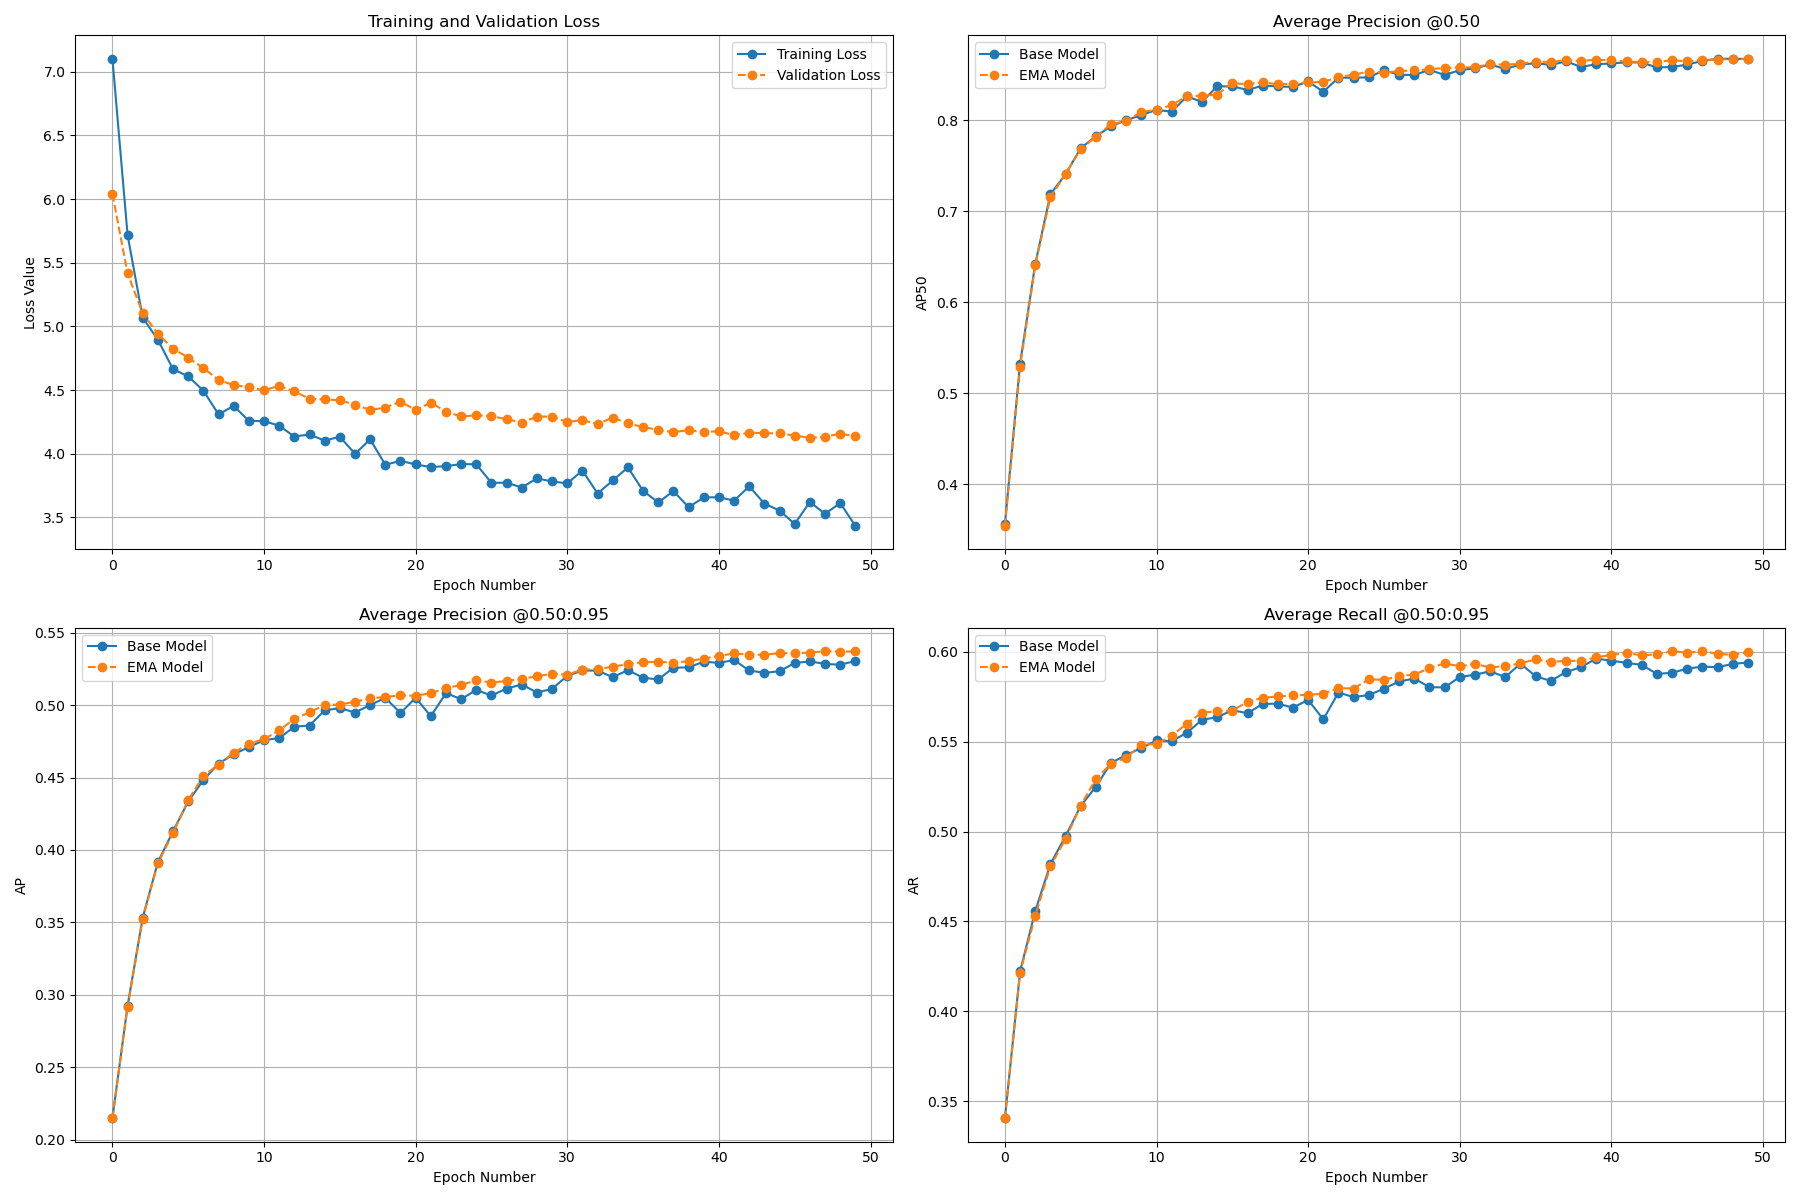

In [6]:
from PIL import Image

Image.open("D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\basketball_output\\metrics_plot.png")

In [10]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [11]:
cleanup_gpu_memory(model, verbose=True)

[INFO] CUDA is not available. No GPU cleanup needed.


In [2]:
from rfdetr import RFDETRBase

model = RFDETRBase()

DATASET_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\basketball-player-detection-2.v13i.coco"
OUTPUT_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\basketball_output"

Loading pretrain weights


In [3]:
model = RFDETRBase(pretrain_weights="D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\basketball_output\\checkpoint_best_total.pth")

Loading pretrain weights


In [4]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{DATASET_DIR}/test",
    annotations_path=f"{DATASET_DIR}/test/_annotations.coco.json",
)

In [7]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

model.optimize_for_inference()
targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 169/169 [00:15<00:00, 11.18it/s]


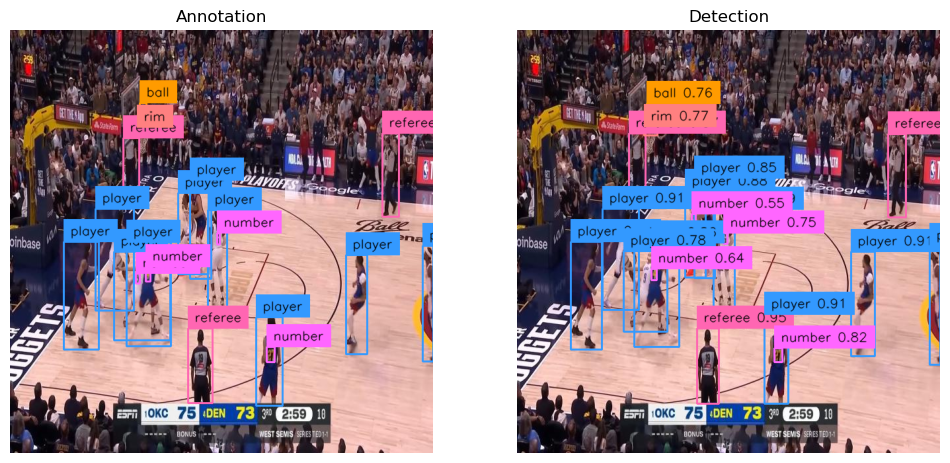

In [8]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])